# Titanic Survival Prediction with Machine Learning

## Project Overview

This is my fifth Python data science project and my first machine learning project.

In this project, I build machine learning models to predict whether a Titanic passenger survived or not.

The goal is to practice the basic machine learning workflow:

- Load real dataset
- Explore data
- Clean missing values
- Create new features
- Encode categorical variables
- Split data into training and validation sets
- Train machine learning models
- Evaluate model performance
- Generate Kaggle submission file

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")

In [16]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [17]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

train.head()

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [18]:
train.shape

train.info()

train.isnull().sum().sort_values(ascending=False)

test.isnull().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Cabin          327
Age             86
Fare             1
Name             0
Pclass           0
PassengerId      0
Sex              0
Parch            0
SibSp            0
Ticket           0
Embarked         0
dtype: int64

## Machine Learning Problem

This is a binary classification problem.

Target variable:

- Survived

Target values:

- 0 = Did not survive
- 1 = Survived

The model will learn patterns from passenger features and predict survival.

In [19]:
train_data = train.copy()
test_data = test.copy()

In [22]:
train_data["FamilySize"] = train_data["SibSp"] + train_data["Parch"] + 1
test_data["FamilySize"] = test_data["SibSp"] + test_data["Parch"] + 1

train_data["IsAlone"] = train_data["FamilySize"].apply(lambda x:1 if x == 1 else 0)
test_data["IsAlone"] = test_data["FamilySize"].apply(lambda x:1 if x == 1 else 0)

train_data[["SibSp", "Parch", "FamilySize", "IsAlone"]].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [23]:
age_median = train_data["Age"].median()
fare_median = train_data["Fare"].median()
embarked_mode = train_data["Embarked"].mode()[0]

train_data["Age"] = train_data["Age"].fillna(age_median)
test_data["Age"] = test_data["Age"].fillna(age_median)

train_data["Fare"] = train_data["Fare"].fillna(fare_median)
test_data["Fare"] = test_data["Fare"].fillna(fare_median)

train_data["Embarked"] = train_data["Embarked"].fillna(embarked_mode)
test_data["Embarked"] = test_data["Embarked"].fillna(embarked_mode)

train_data.isnull().sum().sort_values(ascending=False)

test_data.isnull().sum().sort_values(ascending=False)

Cabin          327
PassengerId      0
Name             0
Sex              0
Age              0
Pclass           0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Family Size      0
FamilySize       0
IsAlone          0
dtype: int64

In [24]:
train_data["Sex"] = train_data["Sex"].map({
    "male": 0,
    "female": 1
})

test_data["Sex"] = test_data["Sex"].map({
    "male": 0,
    "female": 1
})

train_data["Embarked"] = train_data["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2,
})

test_data["Embarked"] = test_data["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2,
})

train_data[["Sex", "Embarked"]].head()

,Sex,Embarked
0,0,0
1,1,1
2,1,0
3,1,0
4,0,0


In [25]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone"
]

target = "Survived"

X = train_data[features]
y = train_data[target]

X.head()

X.info()

X.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Sex         891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Embarked    891 non-null    int64  
 7   FamilySize  891 non-null    int64  
 8   IsAlone     891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB


Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64

In [26]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (712, 9)
X_valid shape: (179, 9)
y_train shape: (712,)
y_valid shape: (179,)


In [29]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_valid)
logistic_accuracy = accuracy_score(y_valid, logistic_predictions)
print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")

Logistic Regression Accuracy: 0.7989


Classification Report - Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



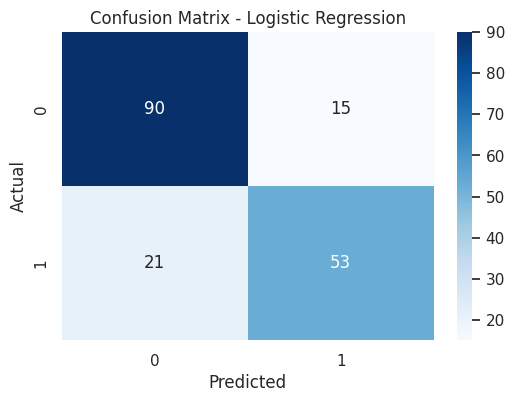

In [33]:
print(f"Classification Report - Logistic Regression")
print(classification_report(y_valid, logistic_predictions))

logistic_cm = confusion_matrix(y_valid, logistic_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(logistic_cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [35]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_valid)

rf_accuracy = accuracy_score(y_valid, rf_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8212


Classification Report - Random Forest
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



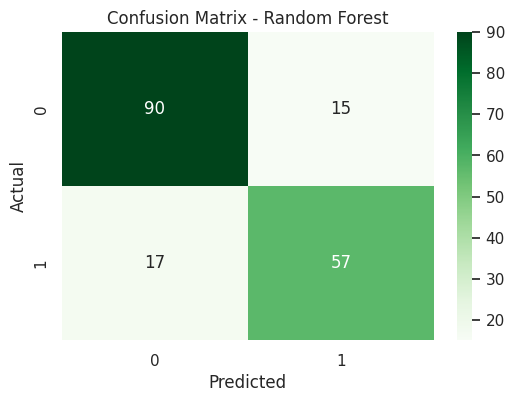

In [38]:
print("Classification Report - Random Forest")
print(classification_report(y_valid, rf_predictions))

rf_cm = confusion_matrix(y_valid, rf_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

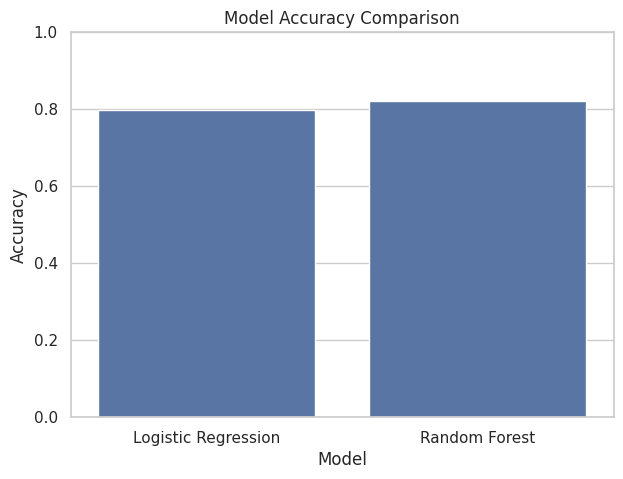

In [40]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy]
})

model_comparison

plt.figure(figsize=(7, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.show()

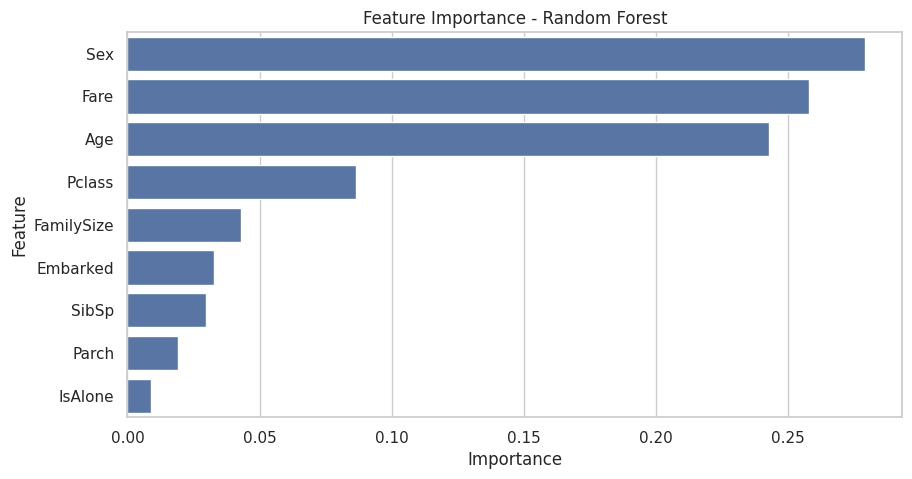

In [43]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

plt.figure(figsize=(10, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [45]:
if rf_accuracy >= logistic_accuracy:
    best_model = random_forest_model
    best_model_name = "Random Forest"
    best_accuracy = rf_accuracy
else:
    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_accuracy = logistic_accuracy

print(f"Best Model: {best_model_name}")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")

Best Model: Random Forest
Best Validation Accuracy: 0.8212


In [46]:
best_model.fit(X,y)

print("Best model trained on full training data.")

Best model trained on full training data.


In [49]:
X_test = test_data[features]
X_test.head()

X_test.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64

In [50]:
test_predictions = best_model.predict(X_test)
test_predictions[:10]

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 0])

In [51]:
submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": test_predictions
})

submission.head()

submission.to_csv("/kaggle/working/titanic_submission.csv", index=False)
print("Submission file created successfully.")

os.listdir("/kaggle/working")

Submission file created successfully.


['.virtual_documents', 'titanic_submission.csv']

In [55]:
from IPython.display import FileLink

FileLink("/kaggle/working/titanic_submission.csv")

/kaggle/working/titanic_submission.csv

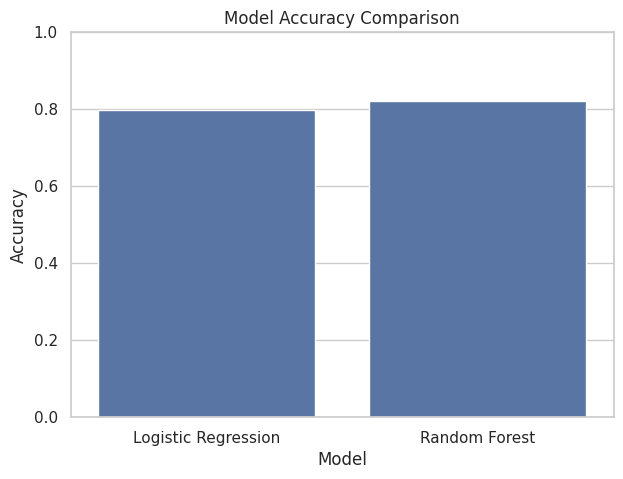

/kaggle/working/titanic_model_comparison.png

In [59]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.ylabel("Accuracy")

plt.savefig("/kaggle/working/titanic_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

FileLink("/kaggle/working/titanic_model_comparison.png")

In [ ]:
## Key Findings

From this Titanic machine learning project, I found that:

1. Logistic Regression can be used as a simple baseline model.
2. Random Forest performed well because it can capture more complex patterns.
3. Important features include Sex, Pclass, Fare, Age, and FamilySize.
4. Feature engineering helped create useful variables such as FamilySize and IsAlone.
5. Handling missing values is an important step before training a machine learning model.
6. Model accuracy helps compare different machine learning algorithms.

## What I Learned

In this project, I practiced:

- Preparing data for machine learning
- Handling missing values
- Encoding categorical variables
- Creating new features
- Splitting data into training and validation sets
- Training classification models
- Evaluating model accuracy
- Using confusion matrix and classification report
- Creating a Kaggle submission file

## Next Step

The next step is to improve the model using:

- More feature engineering
- Cross-validation
- Hyperparameter tuning
- Advanced models such as XGBoost or LightGBM